# Comparison of the Z-statistic and t-statistic

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/z_t_comparison.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-21*

## Learning objectives

- Use `scipy.stats.norm` and `scipy.stats.t` to get critical values (`.ppf`) and tail probabilities (`.cdf`) instead of look-up tables.
- Visualize the standard normal PDF with shaded $\pm 1\sigma$, $\pm 2\sigma$, $\pm 3\sigma$ regions, and recognize the 68/95/99.7 empirical rule.
- Compare the t-distribution at small and large degrees of freedom against the standard normal.

This notebook is a short tour of two distributions you will use constantly for hypothesis testing about means: the **standard normal** (Z-statistic) and **Student's t** (t-statistic). The point is to get comfortable calling `scipy.stats` for critical values and tail probabilities so you never have to consult a printed lookup table again.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (5.0, 3.5)

## Z-statistic

Step 1: plot the PDF of a Gaussian. In Python, use `scipy.stats.norm.pdf` and specify the mean and standard deviation. Below we use a standard normal (mean 0, standard deviation 1).

In [2]:
x = np.arange(-6, 6, 0.01)
z = stats.norm.pdf(x, loc=0, scale=1)

Plot the PDF with three shaded regions marking $\pm 1\sigma$, $\pm 2\sigma$, and $\pm 3\sigma$ — the 68/95/99.7 empirical rule.

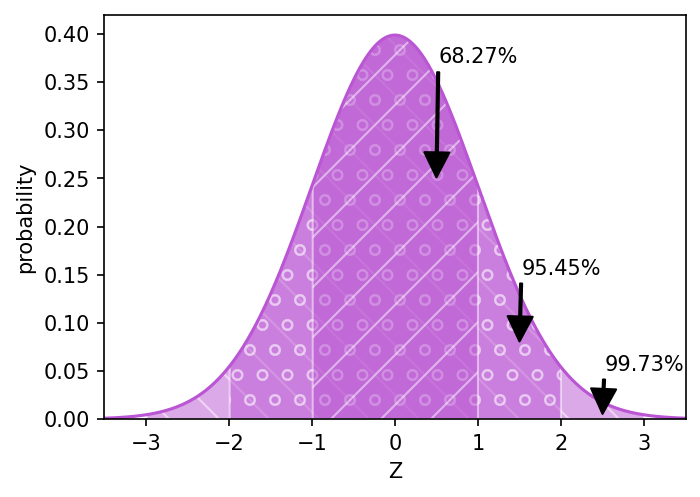

In [3]:
plt.figure()
plt.plot(x, z, color="mediumorchid", label="Z")

plt.ylim(0, 0.42)
plt.xticks(np.arange(-5, 5, 1))
plt.xlim(-3.5, 3.5)
plt.xlabel("Z")
plt.ylabel("probability")

# +/- 3 sigma, 99.73%
xshade = np.where(abs(x) <= 3.0, x, np.nan)
zshade = np.where(abs(x) <= 3.0, z, np.nan)
plt.fill_between(
    xshade, zshade, 0, hatch="\\", color="mediumorchid", edgecolor="white", alpha=0.5
)
plt.annotate(
    "68.27%",
    xy=(0.5, 0.25),
    xytext=(1.0, 0.37),
    arrowprops=dict(facecolor="black", shrink=0.01, width=1),
    horizontalalignment="center",
)

# +/- 2 sigma, 95.45%
xshade = np.where(abs(x) <= 2.0, x, np.nan)
zshade = np.where(abs(x) <= 2.0, z, np.nan)
plt.fill_between(
    xshade, zshade, 0, hatch="o", color="mediumorchid", edgecolor="white", alpha=0.5
)
plt.annotate(
    "95.45%",
    xy=(1.5, 0.08),
    xytext=(2.0, 0.15),
    arrowprops=dict(facecolor="black", shrink=0.01, width=1),
    horizontalalignment="center",
)

# +/- 1 sigma, 68.27%
xshade = np.where(abs(x) <= 1.0, x, np.nan)
zshade = np.where(abs(x) <= 1.0, z, np.nan)
plt.fill_between(
    xshade, zshade, 0, hatch="/", color="mediumorchid", edgecolor="white", alpha=0.5
)
plt.annotate(
    "99.73%",
    xy=(2.5, 0.005),
    xytext=(3.0, 0.05),
    arrowprops=dict(facecolor="black", shrink=0.01, width=1),
    horizontalalignment="center",
)

plt.show()

What is the critical $Z$ value for two-tailed 95% confidence bounds? You may know the answer is $z_c = 1.96$, but if you didn't, here is how to compute it directly:

In [4]:
z_c = stats.norm.ppf(0.975, loc=0, scale=1)
z_c

np.float64(1.959963984540054)

`ppf` is the **percent-point function**, the inverse of the CDF. Tell it what cumulative probability you want (here, 0.975) and it returns the value of $Z$ that integrates up to that probability. `loc` is the mean (0 for standard normal); `scale` is the standard deviation (1).

What about the one-tailed 95% confidence bound?

In [5]:
z_c = stats.norm.ppf(0.95, loc=0, scale=1)
z_c

np.float64(1.6448536269514722)

Or the two-tailed 99% confidence bounds?

In [6]:
z_c = stats.norm.ppf(0.995, loc=0, scale=1)
z_c

np.float64(2.5758293035489004)

Going the other direction, you can ask for the probability of exceeding a particular $Z$ value. Use `cdf` (the cumulative distribution function) and subtract from 1 to get the upper-tail probability.

Example: $Z = 2.2$. What area under the standard normal falls to the right?

In [7]:
prob = 1.0 - stats.norm.cdf(2.2, loc=0, scale=1)
prob

np.float64(0.01390344751349859)

So about 1.4% of the area under a standard normal exceeds $Z = 2.2$. You can see this in the figure below. It is always a good idea to draw a quick sketch and check the answer makes sense — if we had forgotten to subtract from 1.0, we might have thought the probability was 98.6%, which would obviously be wrong given the picture.

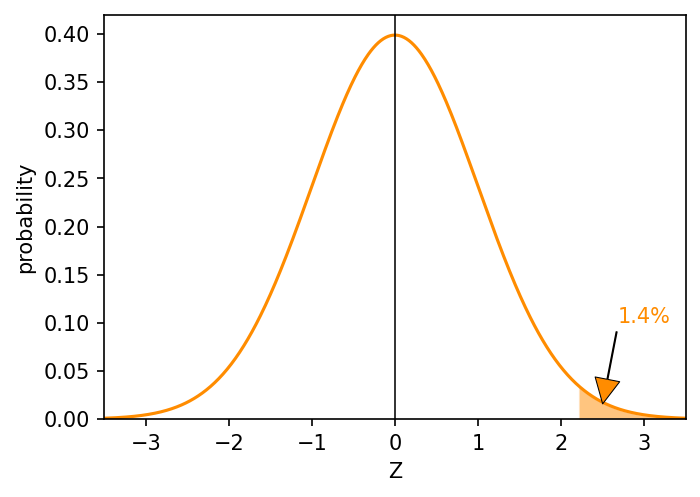

In [8]:
plt.figure()
plt.plot(x, z, color="darkorange", label="Z")

plt.ylim(0, 0.42)
plt.xticks(np.arange(-5, 5, 1))
plt.xlim(-3.5, 3.5)
plt.xlabel("Z")
plt.ylabel("probability")

xshade = np.where(x > 2.2, x, np.nan)
plt.fill_between(xshade, z, 0, color="darkorange", edgecolor="white", alpha=0.5)
plt.annotate(
    f"{prob * 100:.1f}%",
    xy=(2.5, 0.015),
    xytext=(3.0, 0.1),
    arrowprops=dict(facecolor="darkorange", shrink=0.01, width=0.5, linewidth=0.5),
    horizontalalignment="center",
    color="darkorange",
)

plt.axvline(x=0, linewidth=0.75, color="black")
plt.show()

## t-statistic

The t-statistic is similar to $Z$ (the standard normal), except it requires one extra piece of information: the **degrees of freedom** ($\nu$). Below is the $Z$ PDF and t PDFs at $\nu = 4$ and $\nu = 20$. As $\nu$ grows, the t-distribution converges to the standard normal.

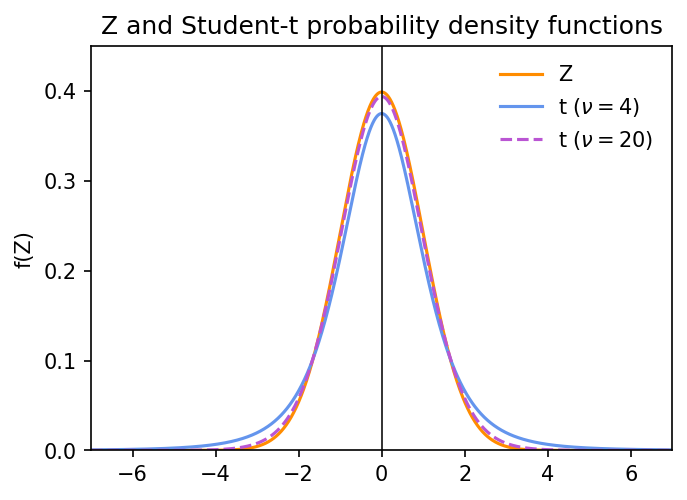

In [9]:
x = np.arange(-10, 10, 0.01)
z = stats.norm.pdf(x, loc=0, scale=1)
t4 = stats.t.pdf(x, df=4)
t20 = stats.t.pdf(x, df=20)

plt.figure()
plt.plot(x, z, color="darkorange", label="Z")
plt.plot(x, t4, linestyle="-", color="cornflowerblue", label=r"t ($\nu = 4$)")
plt.plot(x, t20, linestyle="--", color="mediumorchid", label=r"t ($\nu = 20$)")

plt.title("Z and Student-t probability density functions")
plt.ylabel("f(Z)")
plt.xlim(-7, 7)
plt.ylim(0, 0.45)
plt.yticks(np.arange(0, 0.5, 0.1))
plt.legend(frameon=False)
plt.axvline(x=0, linewidth=0.75, color="black")
plt.show()

The critical $t$ value for two-tailed 95% confidence with $\mathrm{df} = 4$:

In [10]:
t_c = stats.t.ppf(0.975, df=4, loc=0, scale=1)
t_c

np.float64(2.7764451051977934)

Compare the critical regions of the t-distribution ($\mathrm{df}=4$) and the standard normal side by side. The t-distribution has heavier tails, so its critical value sits farther from 0 than $z_c = 1.96$.

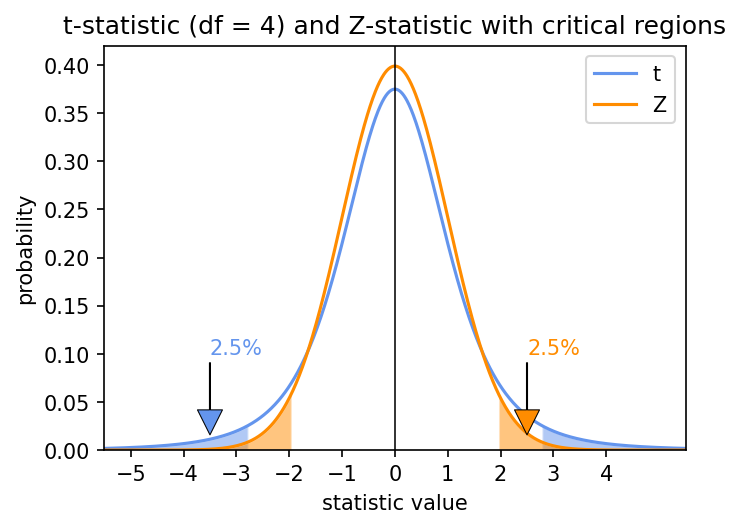

In [11]:
x = np.arange(-10, 10, 0.01)
t = stats.t.pdf(x, df=4, loc=0, scale=1)
z = stats.norm.pdf(x, loc=0, scale=1)
t_c = stats.t.ppf(0.975, df=4, loc=0, scale=1)
z_c = stats.norm.ppf(0.975, loc=0, scale=1)

plt.figure()
plt.plot(x, t, color="cornflowerblue", label="t")
plt.plot(x, z, color="darkorange", label="Z")

# t critical regions
xshade = np.where(x > t_c, x, np.nan)
plt.fill_between(xshade, t, 0, color="cornflowerblue", edgecolor="white", alpha=0.5)
xshade = np.where(x < -t_c, x, np.nan)
plt.fill_between(xshade, t, 0, color="cornflowerblue", edgecolor="white", alpha=0.5)
plt.annotate(
    "2.5%",
    xy=(-3.5, 0.015),
    xytext=(-3.0, 0.1),
    arrowprops=dict(facecolor="cornflowerblue", shrink=0.01, width=0.5, linewidth=0.5),
    horizontalalignment="center",
    color="cornflowerblue",
)

# Z critical regions
xshade = np.where(x > z_c, x, np.nan)
plt.fill_between(xshade, z, 0, color="darkorange", edgecolor="white", alpha=0.5)
xshade = np.where(x < -z_c, x, np.nan)
plt.fill_between(xshade, z, 0, color="darkorange", edgecolor="white", alpha=0.5)
plt.annotate(
    "2.5%",
    xy=(2.5, 0.015),
    xytext=(3.0, 0.1),
    arrowprops=dict(facecolor="darkorange", shrink=0.01, width=0.5, linewidth=0.5),
    horizontalalignment="center",
    color="darkorange",
)

plt.legend()
plt.ylim(0, 0.42)
plt.xticks(np.arange(-5, 5, 1))
plt.xlim(-5.5, 5.5)
plt.xlabel("statistic value")
plt.ylabel("probability")
plt.title("t-statistic (df = 4) and Z-statistic with critical regions")
plt.axvline(x=0, linewidth=0.75, color="black")
plt.show()

Just like for Z, if you get a value of $t = 2.2$ and want to know the upper-tail probability under the t-distribution with $\mathrm{df} = 4$:

In [12]:
prob = 1 - stats.t.cdf(2.2, df=4, loc=0, scale=1)
prob

np.float64(0.046326335089817317)

About 4.6% — close to 5%, but notice that the same value of 2.2 gave only 1.4% under the standard normal. The heavier tails of the t-distribution put more probability mass out at extreme values, which is exactly why we use t for inference with small sample sizes.

## Wrap-up

- `scipy.stats.norm` and `scipy.stats.t` give you `.pdf`, `.cdf`, and `.ppf` — everything a printed table would. No tables required.
- The 68/95/99.7 empirical rule (areas under $\pm 1, 2, 3$ standard deviations of the normal) is worth memorizing as a sanity check.
- The t-distribution has heavier tails than the standard normal at small $\mathrm{df}$ and converges to the normal as $\mathrm{df} \to \infty$. Use t when the sample size is small (or, more precisely, when you are estimating $\sigma$ from the sample rather than knowing it).